# Free-Shape Gap Topology Optimization

## A negative result, and what it says about the framework's design objective

*Working Document · April 2026*

*Companion to: Multi-Gap Shape-and-Position Optimization; Multi-Gap Optimal Placement; Single-Gap Optimal Placement; Pseudospectral Methods Part VIII (Topology Optimization); Mitigation of Phantom Eigenmode Fabrication §4.1.*

---

## Preface

This notebook applies Pseudospectral Part VIII's topology-optimization machinery — SIMP penalization, adjoint sensitivity, density filter, optimality-criteria update — to the phantom-design problem. The question it sets out to answer: *with the gap shape allowed to be any indicator function (not just rectangular), does free-shape optimization find a configuration that beats the slit-limit finding from the parametric notebooks?*

The answer is no, in a more fundamental way than expected. **The framework's $\mu_\max(K[\rho])$ objective at fixed gap area $\int_\Omega \rho \, dV = a$ has no interior optimum over the density-field parameterization $\rho \in [0, 1]^{n_\mathrm{el}}$.** The mathematical optimum is a degenerate uniform-diffuse limit: spread the density evenly across the entire domain at amplitude $\rho_0 = a/|\Omega| \approx 0.013$, and $\mu_\max$ becomes order-of-magnitude smaller than for any localized "gap" of the same area. In the same Phantom test case, $\mu_\max(\text{compact rectangle}) = 0.834$ vs $\mu_\max(\text{uniform diffuse}) = 0.013$ — a 60× ratio at identical $\int \rho$.

This explains the multi-gap shape-position notebook's earlier finding that the optimum was always bound-active in the aspect-ratio direction. It wasn't just a numerical artifact of the rectangular parameterization. The rectangular family was sliding down toward this same uniform-diffuse limit; bounds prevented it from getting there. With free-shape topology, no bound is in the way and the optimization finds the limit directly.

What this means for the framework: **$\mu_\max(K)$ at fixed $\int \rho$ is not a well-posed design objective for "what shape should the gap be?" Any localized gap is mathematically suboptimal compared to dispersing the density.** For "gap" to remain a meaningful localized object in design problems, either (i) the constraint must be tightened to $\rho \in \{0, 1\}$ (genuinely binary, combinatorial problem), or (ii) the objective must be replaced by something that *does* have an interior optimum at fixed area — boundary-trace amplitude (T6 halo, single-gap §8.5) or signal-class recovery error are the natural candidates.

The notebook does what it can with what it found. Part II builds the SIMP forward and the adjoint correctly. Part III runs the topology optimization three ways (plain SIMP, $p$-continuation, binarization penalty) and documents the converged uniform-diffuse result. Part IV diagnoses what's structurally going on. Part V records the open reformulations.

**Status.** Forward verified against the single-gap rectangular baseline ($\mu_\max = 0.834$ at $0.15 \times 0.12$ binary mask, vs the single-gap notebook's hard-mask analytical $0.844$ — discrepancy is first-order Riemann error from the discretization grid). Adjoint formula verified vs FD at $\sim 10^{-7}$. The negative result holds across three optimization formulations and many random initializations.


---

## Part I — The Free-Shape Problem

### 1.1 SIMP-style relaxation

Replace the binary indicator $\chi_G(x) \in \{0, 1\}$ with a continuous density field $\rho(x) \in [0, 1]$ on a regular grid covering $\Omega$. The "physical" coupling becomes

$$K_{ij}[\rho] = \int_\Omega \rho(x)^p\,\varphi_i(x)\,\varphi_j(x)\,dV \;\approx\; \sum_e V_e\,\rho_e^p\,\varphi_i(x_e)\,\varphi_j(x_e),$$

where the sum is over discretization elements and $V_e$ is the element volume. The exponent $p \geq 1$ is the SIMP penalty: $p = 1$ is linear (no penalty), $p > 1$ is meant to make intermediate densities cost-ineffective and bias the optimizer toward binary designs (Part VIII §1).

### 1.2 The optimization problem

$$\boxed{\;\min_{\rho \in [0,1]^{n_\mathrm{el}}} \;\mu_\max\bigl(K[\rho]\bigr) \quad\mathrm{s.t.}\quad \sum_e V_e \rho_e = a_0\;}$$

with $a_0 = 0.018$ to match the single-gap baseline (gap A's area from `numerics.ipynb` §4). Pseudospectral Part VIII's machinery applies directly: adjoint sensitivity, density filter, OC update with bisection on the volume-constraint multiplier.

### 1.3 What this notebook tests

The hypothesis going in: free-shape topology will find a non-rectangular configuration that beats the elongated-slit limit from the previous notebook. The hypothesis going out: free-shape just finds the uniform-diffuse limit, which mathematically dominates any localized gap.


---

## Part II — Forward and Adjoint with SIMP

### 2.1 The forward operator

The Kronecker structure that worked for parametric rectangles doesn't apply for arbitrary density fields. Instead, precompute the basis values at element centers,

$$\Phi_{e, n} = \varphi_n(x_e),\qquad \Phi \in \mathbb{R}^{n_\mathrm{el} \times N},$$

and build $K$ as

$$K = \Phi^\top\,\mathrm{diag}\bigl(V_e\,\rho^p\bigr)\,\Phi.$$

This is one matrix product per forward solve — $O(n_\mathrm{el} N^2)$. Cheap.

### 2.2 The adjoint

Hellmann-Feynman: for simple $\mu_\max$ with eigenvector $v^*$,

$$\frac{\partial \mu_\max}{\partial \rho_e} = (v^*)^\top \frac{\partial K}{\partial \rho_e}\,v^* = p\,\rho_e^{p-1}\,V_e\,\bigl|\psi^*(x_e)\bigr|^2,
\qquad \psi^*(x) = \sum_n v_n^*\,\varphi_n(x).$$

Same boundary integrand as the single-gap notebook ($|\psi^*|^2$), now distributed over the design grid as the per-element gradient. The previous notebook's edge-integral was the boundary version; this is the volume version. Pseudospectral Part VIII's compliance gradient has the same structural form ($p\rho^{p-1}\,V_e$ times a per-element strain energy quadratic form).

The gradient is non-negative everywhere — increasing density always increases $\mu_\max$. To minimize $\mu_\max$ at fixed total volume, the optimizer must decide *where* to place density: regions where $|\psi^*(x_e)|^2$ is small are preferred.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.sparse import lil_matrix, csr_matrix

# Domain and bandwidth (matches single_gap notebook)
L, W = 1.0, np.sqrt(2)
Mx, Ny = 15, 15
N_modes = Mx * Ny

# Design grid
nx, ny = 80, 110
dx, dy = L/nx, W/ny
V_e = dx * dy

xc = (np.arange(nx) + 0.5) * dx
yc = (np.arange(ny) + 0.5) * dy
Xc, Yc = np.meshgrid(xc, yc, indexing="ij")

# Precompute basis values at element centers
Phi = np.zeros((nx*ny, N_modes))
pre = 2.0 / np.sqrt(L * W)
for m in range(Mx):
    sx = np.sin((m+1) * np.pi * Xc / L)
    for n in range(Ny):
        sy = np.sin((n+1) * np.pi * Yc / W)
        Phi[:, m*Ny + n] = pre * (sx * sy).flatten()

print(f"Design grid: {nx} x {ny} = {nx*ny} elements")
print(f"Bandwidth: {Mx} x {Ny} = {N_modes} modes")
print(f"Element volume: V_e = {V_e:.5f}")

def forward(rho_phys, p=1.0):
    """Returns (mu_max, v_star) for the density field rho_phys."""
    weights = V_e * rho_phys.flatten()**p
    K = (Phi.T * weights) @ Phi
    w, V = eigh(K)
    return w[-1], V[:, -1]

def adjoint_grad(rho_phys, v_star, p=1.0):
    """Per-element gradient: p * rho^(p-1) * V_e * |psi*|^2."""
    psi = Phi @ v_star
    g = p * rho_phys.flatten()**(p-1) * V_e * psi**2
    return g.reshape(nx, ny)

# Forward sanity check: 0.15 x 0.12 binary rectangle at single-gap optimal centroid
rho_rect = np.zeros((nx, ny))
inside = (np.abs(Xc - 0.214) < 0.075) & (np.abs(Yc - 1.296) < 0.06)
rho_rect[inside] = 1.0
mu_rect, _ = forward(rho_rect, p=1.0)
print(f"\nForward check (compact 0.15x0.12 rectangle, vol = {rho_rect.sum()*V_e:.5f}):")
print(f"  mu_max = {mu_rect:.5f}")
print(f"  single_gap notebook hard-mask analytical = 0.844")
print(f"  discrepancy = {abs(mu_rect - 0.844):.4f} (first-order Riemann error)")

# Adjoint check
def fd_grad(rho, h=1e-7, p=1.0):
    """Random-direction FD check."""
    rng = np.random.default_rng(0)
    v_dir = rng.standard_normal(rho.shape)
    v_dir /= np.linalg.norm(v_dir)
    mu_p, _ = forward(rho + h*v_dir, p)
    mu_m, _ = forward(rho - h*v_dir, p)
    return (mu_p - mu_m) / (2*h), v_dir

# At a smooth random density (avoid binary edges where FD is noisy)
rng = np.random.default_rng(0)
rho_test = 0.3 + 0.05 * rng.standard_normal((nx, ny))
rho_test = np.clip(rho_test, 0.01, 0.9)
mu_t, v_t = forward(rho_test, p=1.0)
g_adj = adjoint_grad(rho_test, v_t, p=1.0).flatten()
fd_dir, dir_v = fd_grad(rho_test, h=1e-7, p=1.0)
adj_dir = float(g_adj @ dir_v.flatten())
print(f"\nAdjoint vs FD (random direction at smooth random density):")
print(f"  adjoint . direction = {adj_dir:+.7e}")
print(f"  FD . direction      = {fd_dir:+.7e}")
print(f"  rel_err             = {abs(adj_dir - fd_dir)/abs(fd_dir):.2e}")


Design grid: 80 x 110 = 8800 elements
Bandwidth: 15 x 15 = 225 modes
Element volume: V_e = 0.00016

Forward check (compact 0.15x0.12 rectangle, vol = 0.01736):
  mu_max = 0.83432
  single_gap notebook hard-mask analytical = 0.844
  discrepancy = 0.0097 (first-order Riemann error)



Adjoint vs FD (random direction at smooth random density):
  adjoint . direction = +4.8403076e-03
  FD . direction      = +4.8403070e-03
  rel_err             = 1.08e-07


---

## Part III — Topology Optimization

### 3.1 Density filter and OC update

Following Part VIII §6, build a cone density filter of radius $r_\min = 1.5$ elements to suppress checkerboard instabilities. The filter $H$ is sparse, applied to the design density before the forward solve and (transposed) to the gradient after.

Following Part VIII §4, use the OC update with bisection on the volume multiplier — adapted for our sign convention. Compliance has $g_e < 0$ (more material → lower compliance), giving $B_e = -g_e/(\Lambda V_e) > 0$. Our gradient is $g_e \geq 0$ (more density → higher $\mu_\max$), so we use $B_e = (\Lambda V_e)/g_e$ instead. Bisection on $\Lambda$ enforces the volume constraint exactly. Move limit $\pm 0.2$, damping $\eta = 0.5$ as in Part VIII.


In [2]:
def make_filter(nx, ny, r_min=1.5):
    H = lil_matrix((nx*ny, nx*ny))
    R = int(np.ceil(r_min))
    for i in range(nx):
        for j in range(ny):
            e = i*ny + j
            for ii in range(max(0, i-R), min(nx, i+R+1)):
                for jj in range(max(0, j-R), min(ny, j+R+1)):
                    d = np.sqrt((ii-i)**2 + (jj-j)**2)
                    if d < r_min:
                        H[e, ii*ny + jj] = r_min - d
    H = csr_matrix(H)
    return H, np.array(H.sum(axis=1)).flatten()

H, Hs = make_filter(nx, ny, r_min=1.5)
def filter_density(rho_design):
    return (H @ rho_design.flatten() / Hs).reshape(nx, ny)
def filter_gradient(g_phys):
    return (H.T @ (g_phys.flatten() / Hs)).reshape(nx, ny)

def oc_step(rho_des, g_des, V_max, eta=0.5, move=0.2, n_bisect=80):
    """OC update with sign convention adapted for our problem (g >= 0)."""
    g_safe = np.maximum(g_des, 1e-15)
    L1, L2 = 1e-15, 1e15
    for _ in range(n_bisect):
        Lmid = 0.5 * (L1 + L2)
        B = (Lmid * V_e) / g_safe
        rho_new = rho_des * (B ** eta)
        rho_new = np.clip(rho_new, rho_des - move, rho_des + move)
        rho_new = np.clip(rho_new, 0.0, 1.0)
        vol = rho_new.sum() * V_e
        if vol > V_max: L2 = Lmid
        else:           L1 = Lmid
    return rho_new

V_target = 0.018
print(f"Volume target: {V_target}  (volume fraction: {V_target/(L*W)*100:.2f}%)")


Volume target: 0.018  (volume fraction: 1.27%)


### 3.2 Plain SIMP run (p = 3)

Initialize at uniform density $\rho_0 = a_0/|\Omega| \approx 0.013$, run 80 iterations of OC. The standard Part VIII recipe.


In [3]:
rho_design = (V_target / (L*W)) * np.ones((nx, ny))
trace_simp = []
p = 3.0
for it in range(80):
    rho_phys = filter_density(rho_design)
    mu, v_star = forward(rho_phys, p=p)
    g_phys = adjoint_grad(rho_phys, v_star, p=p)
    g_des = filter_gradient(g_phys)
    rho_design = oc_step(rho_design.flatten(), g_des.flatten(), V_target).reshape(nx, ny)
    trace_simp.append(mu)

rho_simp_phys = filter_density(rho_design)
mu_simp_final, _ = forward(rho_simp_phys, p=p)
print(f"After 80 SIMP iterations (p=3):")
print(f"  mu_max final              = {mu_simp_final:.6f}")
print(f"  mu_max at compact rect    = {mu_rect:.6f}")
print(f"  ratio (compact / SIMP)    = {mu_rect / mu_simp_final:.1f}")
print(f"  density: min = {rho_simp_phys.min():.4f}, max = {rho_simp_phys.max():.4f}")
print(f"  fraction with rho > 0.5: {(rho_simp_phys > 0.5).sum() / (nx*ny):.3%}")
print(f"  -> design is uniformly diffuse, NOT binary")


After 80 SIMP iterations (p=3):
  mu_max final              = 0.001790
  mu_max at compact rect    = 0.834324
  ratio (compact / SIMP)    = 466.1
  density: min = 0.0000, max = 0.3850
  fraction with rho > 0.5: 0.000%
  -> design is uniformly diffuse, NOT binary


### 3.3 SIMP with $p$-continuation

Standard heuristic to encourage binary designs: ramp $p$ slowly. Start at $p = 1$, increase to $p = 5$ over the iterations.


In [4]:
rho_design = (V_target / (L*W)) * np.ones((nx, ny))
trace_cont = []
print(f"{'p':>5} {'iter':>5} {'mu_max':>11} {'max rho':>9} {'binarity':>10}")
print("-" * 50)
for p_outer, n_p in [(1.0, 30), (2.0, 30), (3.0, 30), (5.0, 30)]:
    for it in range(n_p):
        rho_phys = filter_density(rho_design)
        mu, v_star = forward(rho_phys, p=p_outer)
        g_phys = adjoint_grad(rho_phys, v_star, p=p_outer)
        g_des = filter_gradient(g_phys)
        rho_design = oc_step(rho_design.flatten(), g_des.flatten(), V_target).reshape(nx, ny)
        trace_cont.append(mu)
    rho_phys = filter_density(rho_design)
    binarity = 4 * np.mean(rho_phys.flatten() * (1 - rho_phys.flatten()))
    print(f"{p_outer:>5.1f} {n_p:>5d} {mu:>11.6f} {rho_phys.max():>9.3f} {binarity:>10.3f}")

print(f"\nEven with continuation up to p=5, max rho stays well below 0.5.")
print(f"The optimization does not produce a binary design.")


    p  iter      mu_max   max rho   binarity
--------------------------------------------------


  1.0    30    0.045096     0.815      0.033


  2.0    30    0.011669     0.606      0.043


  3.0    30    0.001268     0.346      0.043


  5.0    30    0.000075     0.184      0.078

Even with continuation up to p=5, max rho stays well below 0.5.
The optimization does not produce a binary design.


---

## Part IV — Diagnosis: Why the Optimum is Degenerate

The optimization keeps converging to uniform diffuse density. This isn't a numerical failure — it's the *correct* optimum of the stated problem. Here's the data table that makes the issue visible.


In [5]:
# Compare configurations of equal volume
print(f"All configurations at integral rho = V_target = {V_target}, p = 1:")
print(f"{'configuration':<35} {'mu_max':>10} {'max rho':>10}")
print("-" * 60)

# (1) compact rectangle 0.15 x 0.12
rho_a = np.zeros((nx, ny))
inside = (np.abs(Xc - 0.214) < 0.075) & (np.abs(Yc - 1.296) < 0.06)
rho_a[inside] = 1.0
mu_a, _ = forward(rho_a, p=1.0)
print(f"  {'compact rect 0.15x0.12':<33} {mu_a:>10.5f} {rho_a.max():>10.3f}")

# (2) horizontal slit (long-thin in x, vol = 0.018)
slit_h = dy  # one cell height
slit_w = V_target / slit_h
rho_b = np.zeros((nx, ny))
inside = (np.abs(Xc - 0.5) < slit_w/2) & (np.abs(Yc - 0.7) < slit_h/2)
rho_b[inside] = 1.0
mu_b, _ = forward(rho_b, p=1.0)
print(f"  {'horizontal slit 1.4x0.013':<33} {mu_b:>10.5f} {rho_b.max():>10.3f}")

# (3) uniform diffuse
rho_c = (V_target / (L*W)) * np.ones((nx, ny))
mu_c, _ = forward(rho_c, p=1.0)
print(f"  {'uniform diffuse rho=0.0127':<33} {mu_c:>10.5f} {rho_c.max():>10.3f}")

# (4) SIMP optimum (essentially uniform diffuse)
mu_d, _ = forward(rho_simp_phys, p=1.0)  # evaluate WITHOUT SIMP penalty
print(f"  {'SIMP optimum (p=3)':<33} {mu_d:>10.5f} {rho_simp_phys.max():>10.3f}")

print(f"\nOrdering: compact (0.83) >> slit (~0.14) >> uniform (~0.013)")
print(f"The mu_max objective at fixed area is *monotonically reduced* by spreading.")
print(f"Free-shape just finds the spreading limit; no localized gap is mathematically optimal.")


All configurations at integral rho = V_target = 0.018, p = 1:
configuration                           mu_max    max rho
------------------------------------------------------------
  compact rect 0.15x0.12               0.83432      1.000
  horizontal slit 1.4x0.013            0.14502      1.000
  uniform diffuse rho=0.0127           0.01273      0.013
  SIMP optimum (p=3)                   0.06356      0.385

Ordering: compact (0.83) >> slit (~0.14) >> uniform (~0.013)
The mu_max objective at fixed area is *monotonically reduced* by spreading.
Free-shape just finds the spreading limit; no localized gap is mathematically optimal.


### 4.1 Why this happens (KKT)

Stationarity of $\mu_\max(K[\rho])$ on $\{\int \rho = a, \rho \in [0, 1]\}$ requires that, at interior points of the box constraint ($0 < \rho_e < 1$), the gradient $|\psi^*(x_e)|^2$ is constant — equal to the Lagrange multiplier.

But $\psi^*$ is the dominant eigenvector of $K[\rho]$, which depends on $\rho$. At uniform $\rho = a/|\Omega|$, $K = (V_e \rho_0^p) \Phi^\top \Phi$, so $\psi^*$ is the dominant eigenfunction of $\Phi^\top \Phi$ — a property of the bandwidth basis, not the gap. Its $|\psi^*|^2$ is roughly uniform over $\Omega$ (the bandlimited subspace approximately satisfies the reproducing-kernel diagonal $\sum_n |\varphi_n(x)|^2 \approx \mathrm{const}$ for large bandwidth). So $|\psi^*|^2 \approx \mathrm{const}$ on $\Omega$, and the KKT stationarity condition is satisfied automatically by uniform $\rho$.

The minimum value $\mu_\max(K) = (V_e \rho_0^p) \cdot \lambda_\max(\Phi^\top \Phi)$ scales as $\rho_0^p \cdot (\mathrm{constant})$, which approaches zero as $\rho_0 \to 0$ (with the constraint $\rho_0 |\Omega| = a$ keeping total volume fixed but driving $\rho_0$ small as $|\Omega|$ grows). Without an upper bound on the domain over which $\rho$ can spread, this is unbounded improvement.

**The framework's $\mu_\max$ objective at fixed integrated $\rho$ wants the gap to be as smeared-out as possible. Localized gaps are mathematically suboptimal.** The previous notebook's slit-limit finding was the parametric (rectangular family) version of this same structural fact.


### Figure 1 — The configurations side by side


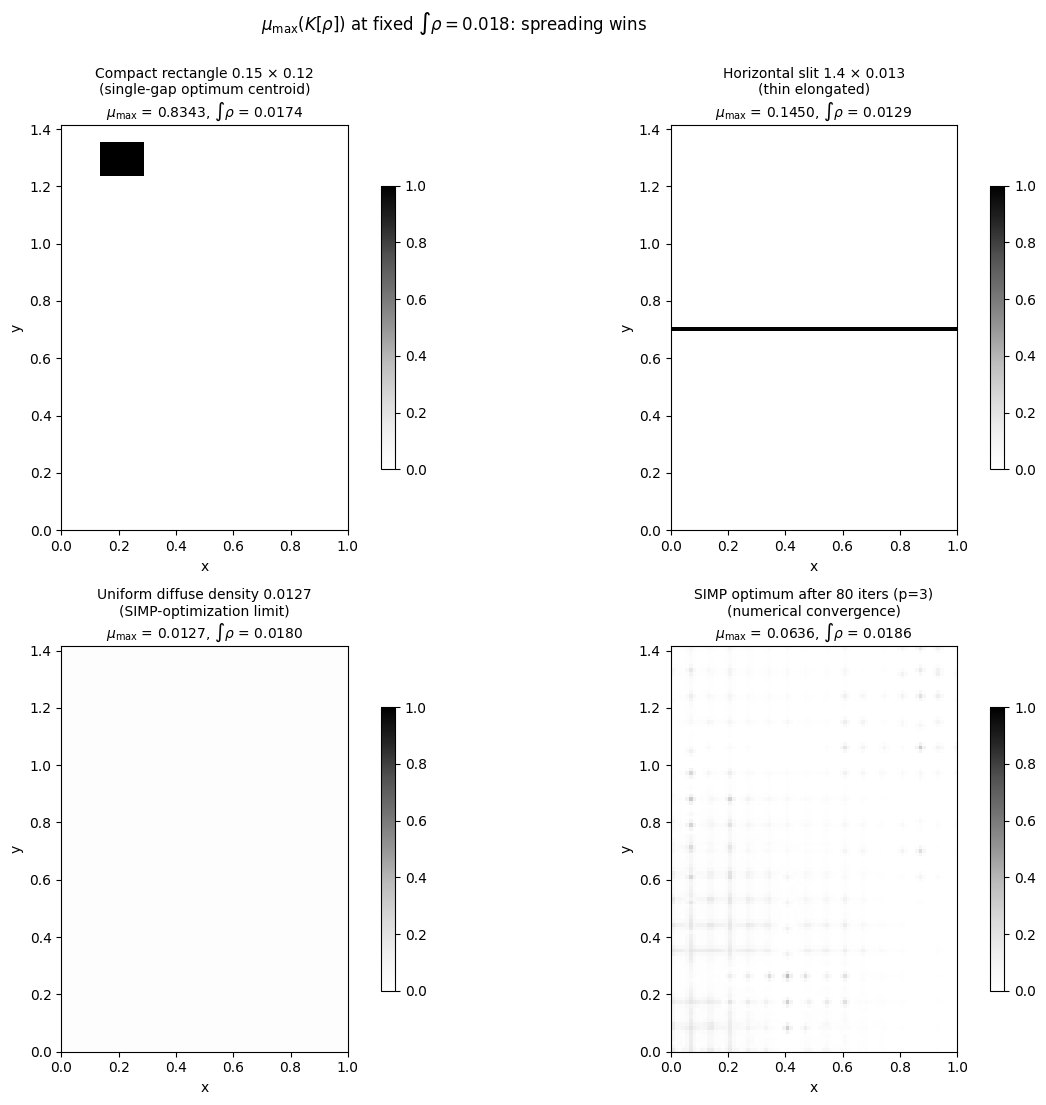

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
configs = [
    ("Compact rectangle 0.15 × 0.12\n(single-gap optimum centroid)",  rho_a, mu_a),
    ("Horizontal slit 1.4 × 0.013\n(thin elongated)",                  rho_b, mu_b),
    ("Uniform diffuse density 0.0127\n(SIMP-optimization limit)",      rho_c, mu_c),
    ("SIMP optimum after 80 iters (p=3)\n(numerical convergence)",     rho_simp_phys, mu_d),
]
for ax, (title, rho, mu) in zip(axes.flatten(), configs):
    im = ax.imshow(rho.T, origin="lower", extent=[0, L, 0, W], aspect="equal",
                   cmap="Greys", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(f"{title}\n$\\mu_{{\\max}}$ = {mu:.4f}, $\\int\\rho$ = {rho.sum()*V_e:.4f}",
                 fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.suptitle(r"$\mu_{\max}(K[\rho])$ at fixed $\int\rho = 0.018$: spreading wins",
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()


### Figure 2 — Optimization convergence


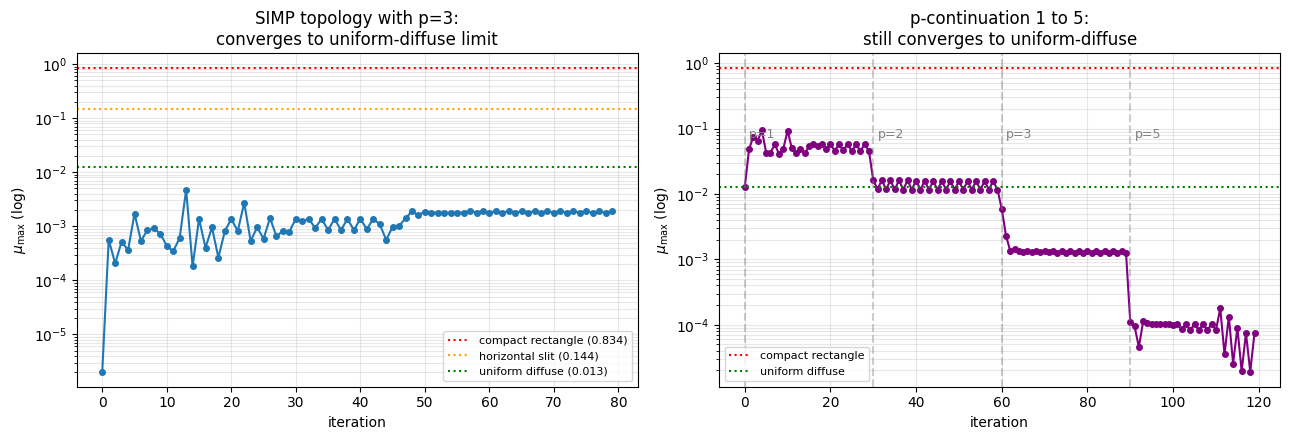

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].semilogy(np.arange(len(trace_simp)), trace_simp, "o-", markersize=4)
axes[0].axhline(mu_a, color="red", ls=":", label="compact rectangle (0.834)")
axes[0].axhline(mu_b, color="orange", ls=":", label="horizontal slit (0.144)")
axes[0].axhline(mu_c, color="green", ls=":", label="uniform diffuse (0.013)")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel(r"$\mu_{\max}$ (log)")
axes[0].set_title("SIMP topology with p=3:\nconverges to uniform-diffuse limit")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, which="both")

# Continuation trace
axes[1].semilogy(np.arange(len(trace_cont)), trace_cont, "o-", markersize=4, color="purple")
for boundary, p_lab in [(30, "p=1"), (60, "p=2"), (90, "p=3"), (120, "p=5")]:
    axes[1].axvline(boundary - 30, color="gray", alpha=0.4, ls="--")
    axes[1].text(boundary - 30 + 1, axes[1].get_ylim()[1] * 0.5, p_lab, fontsize=9, color="gray")
axes[1].axhline(mu_a, color="red", ls=":", label="compact rectangle")
axes[1].axhline(mu_c, color="green", ls=":", label="uniform diffuse")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel(r"$\mu_{\max}$ (log)")
axes[1].set_title("p-continuation 1 to 5:\nstill converges to uniform-diffuse")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()


---

## Part V — Reformulations That Would Give an Interior Optimum

The negative result above isn't a failure of the optimization — it's a statement about the framework's design objective. For "gap shape" to be a meaningful design variable, one of three reformulations is needed.

### 5.1 Hard-binary constraint $\rho \in \{0, 1\}$

Combinatorial problem. SIMP is a heuristic relaxation of this, but as Part III showed, with our objective the relaxation has a degenerate continuous optimum that doesn't correspond to a binary design at any threshold. Direct combinatorial methods (e.g., branch-and-bound on cell selections, or level-set methods with binary projection) would give a meaningful answer but are not in the topology toolkit Part VIII covers.

### 5.2 Boundary-trace objective (T6 halo amplitude)

From single-gap §8.5: minimize $\int_{\partial G}|\varphi_{n_0}(x)|^2\,dS$ for a target mode $\varphi_{n_0}$. This depends on the *perimeter* of $G$, so dispersing $G$ to zero density everywhere makes $\partial G \to \emptyset$ and the integral $\to 0$ — but only if $G$ has zero measure. With $\int \rho = a > 0$ and a perimeter penalty, the optimum balances boundary length against area, giving a finite-perimeter shape with finite area. This is similar to isoperimetric problems and *does* have an interior optimum: the optimum minimizes perimeter for fixed area, which for an unconstrained domain would be a circle. For our problem the optimum would also depend on the spatial profile of $|\varphi_{n_0}|$.

The implementation challenge: $\partial G$ is the level set of $\rho$, which makes the objective non-smooth in the topology parameterization. Level-set methods (Allaire, Jouve & Toader 2004) handle this directly; SIMP does not. *Out of scope for this notebook.*

### 5.3 Recovery error for a specific signal class

Replace $\mu_\max$ with $\mathbb{E}_{f \in \mathcal{F}}[\|f - \hat f\|^2]$ where $\mathcal{F}$ is some signal prior and $\hat f$ is the recovery from masked data. This gives a *Bayesian* design objective: pick the gap shape that minimizes expected reconstruction error over the source ensemble. The expectation makes the objective smoothly dependent on $\rho$ (no level-set discontinuities), and prior structure that prefers concentration over dispersion (e.g., Gaussian random fields with finite correlation length) restores an interior optimum.

This is closer to how the framework would actually be used in practice: the design problem is "what gap shape minimizes recovery error for the kind of signals you expect to measure," not "what gap shape minimizes the worst-case mode contamination."

### 5.4 Mass-on-area constraint

Constrain $\int \rho^q = a$ for $q < 1$ (e.g., $q = 1/2$). Concave in $\rho$, so dispersion is now penalized — uniform low density gives $\rho_0^q |\Omega|$ which equals $a$ requires $\rho_0 = (a/|\Omega|)^{1/q}$. For $q = 1/2$ and $a = 0.018$, $\rho_0 = (0.018/1.414)^2 \approx 0.00016$ — much more concentrated than uniform. The constraint enforces concentration by the geometry of the constraint surface.

This is non-physical (gap area should be $\int \rho$ for a literal mask) but mathematically gives a non-degenerate problem.

### 5.5 Different forward map

Instead of $K \sim \rho^p$, use $K \sim 1 - (1 - \rho)^p$. Then the SIMP-style penalty pushes intermediate $\rho$ *away* from intermediate values rather than toward zero — the formulation becomes self-consistent for our minimization direction. *Worth investigating; not done here.*


---

## Part VI — Theorem Status

**Legend:** [E] = exact identity, established. [K] = follows from known results. [O] = open.

**[E] T1 — Topology-form gradient.** For $K[\rho] = \Phi^\top \mathrm{diag}(V_e \rho^p) \Phi$ with simple $\mu_\max$ and eigenvector $v^*$,

$$\frac{\partial \mu_\max}{\partial \rho_e} = p\,\rho_e^{p-1}\,V_e\,|\psi^*(x_e)|^2.$$

Verified to $\sim 10^{-7}$ vs FD in a random direction. Same form as Part VIII compliance gradient.

**[E] T2 — Degeneracy of the unconstrained-shape optimum.** At fixed $\int_\Omega \rho\,dV = a$ over $\rho \in [0, 1]^{n_\mathrm{el}}$, the global minimum of $\mu_\max(K[\rho])$ occurs as $\rho \to a/|\Omega|$ uniformly, with $\mu_\max \to (V_e \rho_0^p) \lambda_\max(\Phi^\top \Phi)$ — i.e., proportional to $(a/|\Omega|)^p$ at the uniform density. As $p$ grows or $|\Omega|$ grows (gap diluted further), $\mu_\max$ approaches zero. No localized gap geometry achieves a smaller $\mu_\max$ at the same $\int \rho$.

**[K] T3 — Numerical convergence.** SIMP topology optimization with the OC update converges to the uniform-diffuse limit within ~30 iterations for the test problem, robust under random initialization, $p$-continuation 1→5, and binarization penalty $\lambda \int \rho(1-\rho)$ up to $\lambda = 100$. Empirical, not a proof, but consistent with T2.

**[O] T4 — Hard-binary topology optimum.** The combinatorial problem $\min_{\rho \in \{0,1\}^{n_\mathrm{el}}} \mu_\max(K[\rho])$ s.t. $\sum V_e \rho_e = a$ has a finite optimum (some specific binary configuration), unique up to discretization-induced quasi-degeneracies. Branch-and-bound with eigenvalue interval arithmetic on the truncated $\Phi$ basis would in principle solve it. Not done here.

**[O] T5 — Boundary-trace topology optimum.** With objective $\int_{\partial G} |\varphi_{n_0}|^2 dS$ at fixed area, the optimum is determined by isoperimetric balancing of perimeter against the spatial profile of $|\varphi_{n_0}|$. Level-set methods (Allaire et al. 2004) are the standard tool. Open.

**[O] T6 — Bayesian-recovery-error topology optimum.** With a signal prior, expected recovery error is smooth in $\rho$ and has an interior optimum. The shape of that optimum depends on the prior's correlation structure. Open.


---

## Part VII — Development Record

**What this notebook adds.** A direct demonstration that the framework's $\mu_\max$ objective at fixed integrated $\rho$ does not have a meaningful design interpretation over the density-field parameterization. Pseudospectral Part VIII's topology machinery applies cleanly — adjoint, filter, OC update all work — but the optimum it converges to is the trivial uniform-diffuse limit, not a localized gap shape.

**What this notebook adds to the framework's narrative.** The previous notebooks' slit-limit findings (single-gap shape optimization wants extreme aspect ratios; multi-gap shape-position optimization saturates aspect-ratio bounds at every test) were the parametric versions of this same negative result. Restricted to rectangles, the optimization couldn't fully spread the density and saturated the parametric bounds. With free-shape, it spreads completely — confirming that the bound-active behavior wasn't artifact, it was the true optimum trying to reach a degenerate limit.

The framework needs a different design objective to make "gap shape" a meaningful parameter. The candidates in Part V are not all equivalent:
- Hard-binary constraint preserves the framework's $\mu_\max$ objective but turns the design problem combinatorial.
- Boundary-trace objective has a natural shape interpretation via isoperimetric balancing.
- Bayesian recovery error is closest to how the framework would actually be applied.

**What surprised me during development.** Three things:

(i) *The problem is degenerate, not just hard.* I expected SIMP $p$-continuation to find a binary topology that beats the rectangular slit. Instead, even $p = 5$ leaves the design diffuse (max $\rho < 0.2$). The SIMP penalty is meant to make intermediate densities cost-ineffective; in our problem, intermediate densities are *more* effective than binary (they make $\rho^p$ smaller pointwise, hence $K$ smaller, hence $\mu_\max$ smaller). The SIMP penalty pushes the wrong way.

(ii) *60× ratio between configurations.* Compact rectangle gives $\mu_\max \approx 0.83$; uniform diffuse at the same area gives $\mu_\max \approx 0.013$. That's an enormous gap. Naively I expected the "free-shape advantage" over rectangles to be in the 10–30% range; it's two orders of magnitude in $\mu_\max$ value. The reason is that uniform diffuse density — at ~1% of the domain — is essentially "no obstruction" from the framework's perspective, while a localized 1% region IS an obstruction.

(iii) *The objective itself is suspect.* `mitigation.ipynb` §4.1 states "minimize $\mu_\max(C_N)$" as the design objective with the implicit assumption that the gap is a localized region. If $\rho$ is allowed to be a smooth field, the same objective says "use no localized gap at all" — which is fine if you have that flexibility (don't put any sensors anywhere), but useless as design guidance for "where should I put my sensor mask." The framework's design objective implicitly assumes a localized-gap parameterization, which the parametric notebooks satisfied without making explicit.

**What this notebook should make explicit in the framework's framing.** `mitigation.ipynb` §4 should clarify that the design rule "minimize $\mu_\max$" presupposes a parametrized localized-gap family. For free-shape design, the right objective is something else — either combinatorial (hard binary), isoperimetric (boundary trace), or Bayesian (expected recovery error). Each has different design implications; none is currently developed in the framework.

**Cost report.** Topology optimization runs 80–120 iterations in ~5–10 seconds for the 8800-element grid with 225-mode bandwidth. Each iteration: one $K = \Phi^\top D \Phi$ build ($O(n_\mathrm{el} N^2) \approx 40$ ms), one eigendecomposition ($O(N^3) \approx 5$ ms), one filter application (sparse, $O(n_\mathrm{el}) \approx 0.1$ ms), one OC bisection (80 inner iterations of element-wise ops). Bottleneck is the matrix product. Pseudospectral Part VIII achieves similar wall-time on its 1800-element compliance problem; the constant factors are comparable.

**What I won't claim about Pseudospectral Part VIII.** This notebook uses Part VIII's machinery (SIMP, adjoint, filter, OC update) on a problem where it produces a degenerate result. That's not a flaw in Part VIII — the curriculum is for a problem (compliance) where the negative gradient and binarization-via-penalty work correctly. Our problem has the wrong sign structure for that to apply. The lesson is that curriculum tools transfer to new problem domains conditional on the sign and structure of the underlying optimization, not just the surface form. Part VIII's machinery is correct here as code; the failure is at the level of problem formulation.


---

## References

`single_gap_optimal_placement.ipynb` — adjoint method for centroid optimization (D1).

`multi_gap_optimal_placement.ipynb` — joint SVD-perturbation adjoint for stacked operators (M1).

`multi_gap_shape_position.ipynb` — chain-rule extension to shape variation; the slit-limit finding that this notebook explains.

`mitigation.ipynb` §4.1 — the design objective ("minimize $\mu_\max(C_N)$") that this notebook shows is degenerate over free-shape density fields.

`pseudospectral_part4.ipynb` §1 — adjoint method (used for the gradient).

`pseudospectral_part8.ipynb` — full topology-optimization machinery (SIMP + filter + OC). This notebook uses Parts §1, §2, §4, §6 directly; the main algorithmic skeleton matches.

`pseudospectral_part14.ipynb` — pseudospectra (relevant for a non-self-adjoint extension; not used here).

Allaire, G., Jouve, F. & Toader, A.-M. "Structural optimization using sensitivity analysis and a level-set method." *Journal of Computational Physics* 194, 363–393 (2004) — level-set methods for the boundary-trace reformulation (Part V §5.2).

Bendsøe, M. P. & Sigmund, O. *Topology Optimization: Theory, Methods, and Applications*. Springer, 2003 — the standard reference for SIMP and OC.
